In [1]:
from dtwa_non_integrated import run_dtwa
from fdt import (calculate_correlations, extract_stationary_correlation, 
                fourier_transform_correlation, calculate_responses, fourier_transform_response)
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt

# Dynamics

In [2]:
# Constant Parameters
p = {
    "n_spins": 500,
    "omega_0": 1.0,
    "B_z": 1.0,
    "alpha": 0.05,
    "omega_c": 5.0,
    "s": 1.0,
    "g": 0.35,
    "T": 1.0,
    "initial_direction": jnp.array([0.01, 0.0, 0.99]),
    "n_photons_initial": 0.0,  # Explicitly empty cavity (vacuum state)
    "n_steps": 5_000,
    "n_trajectories": 50_000,
    "batch_size": 10_000
}

key=jax.random.PRNGKey(42)
t_max = 300

_, subkey = jax.random.split(key)
dtwa_keys = jax.random.split(subkey, p['n_trajectories'])

# 1. Setup
t_grid = jnp.linspace(0, t_max, p["n_steps"])
# Defining the magnetic field B along Z
B_field = jnp.zeros((p["n_steps"], 3)).at[:, 2].set(p["B_z"])
j_val = p["n_spins"] / 2.0

# --- KEY FIX ---
# split(key) returns two keys. We unpack them to get one "fresh" subkey.
_, subkey = jax.random.split(key)
# Now we split that single subkey into the required number of trajectories
dtwa_field_keys = jax.random.split(subkey, p['n_trajectories'])
# ----------------

# 3. Run Coupled Non-Markovian TWA Simulation
# This returns BOTH the spin trajectories and explicit cavity trajectories
stats = run_dtwa(
    keys=dtwa_field_keys, 
    t_grid=t_grid, 
    omega_0=p["omega_0"], 
    alpha=p["alpha"],
    omega_c=p["omega_c"], 
    s=p['s'], 
    T=p["T"], 
    B_field=B_field,
    g=p["g"], 
    n_photons_initial=p["n_photons_initial"],
    initial_direction=p["initial_direction"], 
    batch_size=p['batch_size'],
    n_spins=p["n_spins"],
    w_max=20.0,    # Default frequency grid cutoff
    N_w=5000,      # Default frequency steps
    use_noise=True, 
    use_sampling=True
)

Running DTWA of 50000 trajectories in 5 batches: 100%|██████████| 5/5 [04:02<00:00, 48.55s/it]


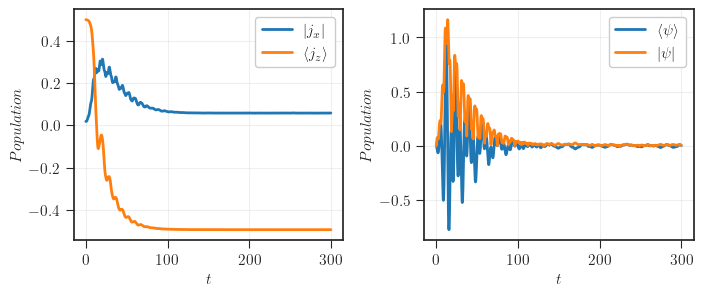

In [3]:
plt.style.use(['seaborn-v0_8-white', './style.mplstyle'])

fig, ax = plt.subplots(1, 2, figsize=(8, 3))
plt.subplots_adjust(wspace=0.3)

ax[0].plot(t_grid, stats['abs_jx'], linewidth = 2, label = r'$\vert j_x \vert$')
ax[0].plot(t_grid, stats['j_z'], linewidth = 2, label = r'$\langle j_z \rangle$')
ax[0].grid(alpha = 0.3)
ax[0].set_xlabel(r'$t$')
ax[0].set_ylabel(r'$Population$')
ax[0].legend()

ax[1].plot(t_grid, jnp.real(stats['mean_psi']), linewidth = 2, label = r'$\langle \psi \rangle$')
ax[1].plot(t_grid, stats['abs_mean_psi'], linewidth = 2, label = r'$\vert \psi \vert$')
ax[1].grid(alpha = 0.3)
ax[1].set_xlabel(r'$t$')
ax[1].set_ylabel(r'$Population$')
ax[1].legend()

plt.show()

# Correlation

In [4]:
C_spin, C_cavity = calculate_correlations(
    keys = dtwa_field_keys, 
    t_grid=t_grid,
    p = p,
    B_field=B_field
)

Running DTWA of 50000 trajectories in 5 batches: 100%|██████████| 5/5 [04:31<00:00, 54.34s/it]


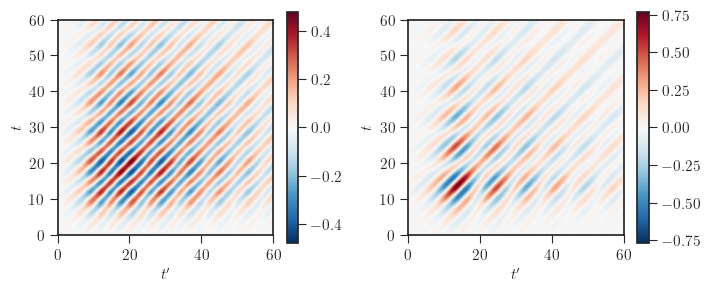

In [5]:
plt.style.use(['seaborn-v0_8-white', './style.mplstyle'])

fig, ax = plt.subplots(1, 2, figsize=(8, 3))
plt.subplots_adjust(wspace=0.3)

t_min, t_max = float(t_grid[0]), float(t_grid[-1])
dt = t_grid[1] - t_grid[0]

max_val_spin = float(jnp.max(jnp.abs(C_spin)))
max_val_cavity = float(jnp.max(jnp.abs(C_cavity)))

im_1 = ax[0].imshow(
        C_spin, 
        cmap='RdBu_r', 
        extent=[t_min, t_max, t_min, t_max], 
        origin='lower',
        vmin=-max_val_spin, 
        vmax=max_val_spin,
        aspect='equal'
    )
ax[0].set_xlim(0, 60)
ax[0].set_ylim(0, 60)
ax[0].set_ylabel(r'$t$')
ax[0].set_xlabel(r"$t'$")
cbar = plt.colorbar(im_1)

im_2 = ax[1].imshow(
        C_cavity, 
        cmap='RdBu_r', 
        extent=[t_min, t_max, t_min, t_max], 
        origin='lower',
        vmin=-max_val_cavity, 
        vmax=max_val_cavity,
        aspect='equal'
    )

ax[1].set_xlim(0, 60)
ax[1].set_ylim(0, 60)
ax[1].set_ylabel(r'$t$')
ax[1].set_xlabel(r"$t'$")
cbar = plt.colorbar(im_2)

In [6]:
t_pulse = 60

steady_start_idx = jnp.searchsorted(t_grid, t_pulse)

C_steady_spin = C_spin[steady_start_idx:, steady_start_idx:]
c_tau_spin = extract_stationary_correlation(C_steady_spin)
tau_grid_spin = jnp.arange(len(c_tau_spin))*dt 

C_steady_cavity = C_cavity[steady_start_idx:, steady_start_idx:]
c_tau_cavity = extract_stationary_correlation(C_steady_cavity)
tau_grid_cavity = jnp.arange(len(c_tau_cavity))*dt 

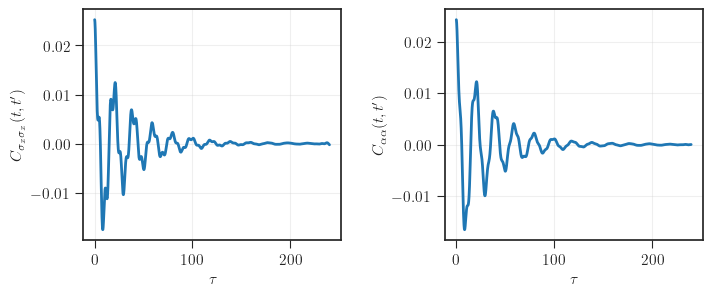

In [7]:
plt.style.use(['seaborn-v0_8-white', './style.mplstyle'])

fig, ax = plt.subplots(1, 2, figsize=(8, 3))
plt.subplots_adjust(wspace=0.4)

ax[0].plot(tau_grid_spin, c_tau_spin, linewidth = 2)
ax[0].grid(alpha = 0.3)
ax[0].set_xlabel(r'$\tau$')
ax[0].set_ylabel(r"$C_{\sigma_x\sigma_x}(t, t')$")

ax[1].plot(tau_grid_cavity, c_tau_cavity, linewidth = 2)
ax[1].grid(alpha = 0.3)
ax[1].set_xlabel(r'$\tau$')
ax[1].set_ylabel(r"$C_{\alpha\alpha}(t, t')$")

plt.show()

In [8]:
w_max = 1.5
N_w = 5_000
w_grid = jnp.linspace(0, w_max, N_w)

S_w_spin = fourier_transform_correlation(c_tau_spin, dt, w_grid)
S_w_cavity = fourier_transform_correlation(c_tau_cavity, dt, w_grid)

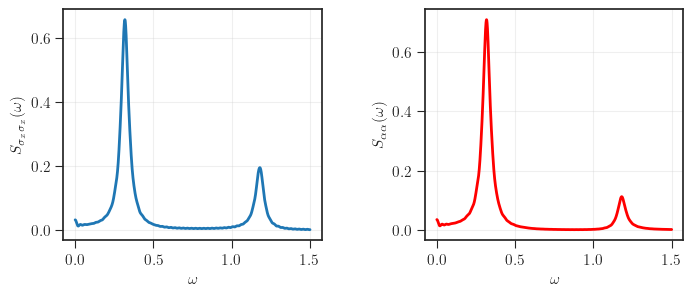

In [9]:
plt.style.use(['seaborn-v0_8-white', './style.mplstyle'])

fig, ax = plt.subplots(1, 2, figsize=(8, 3))
plt.subplots_adjust(wspace=0.4)

ax[0].plot(w_grid, S_w_spin, linewidth = 2)
ax[0].grid(alpha = 0.3)
ax[0].set_xlabel(r'$\omega$')
ax[0].set_ylabel(r"$S_{\sigma_x\sigma_x}(\omega)$")

ax[1].plot(w_grid, S_w_cavity, linewidth = 2, color = 'r')
ax[1].grid(alpha = 0.3)
ax[1].set_xlabel(r'$\omega$')
ax[1].set_ylabel(r"$S_{\alpha\alpha}(\omega)$")

plt.show()

# Response

In [10]:
chi_spin, chi_cav = calculate_responses(
    keys=dtwa_field_keys,
    t_grid=t_grid,
    p=p,
    t_pulse=t_pulse,  # example kick execution time
    epsilon=0.01
)

Simulation 3/3: Perturbed Cavity (Electric): 100%|██████████| 5/5 [04:05<00:00, 49.19s/it]


In [11]:
imag_chi_spin_w = fourier_transform_response(chi_spin, dt, w_grid)
tau_grid_resp_spin = jnp.arange(len(chi_spin))*dt

imag_chi_cav_w = fourier_transform_response(chi_cav, dt, w_grid)
tau_grid_resp_cavity = jnp.arange(len(chi_cav))*dt

Text(0, 0.5, "$\\chi_{\\alpha\\alpha}(t, t')$")

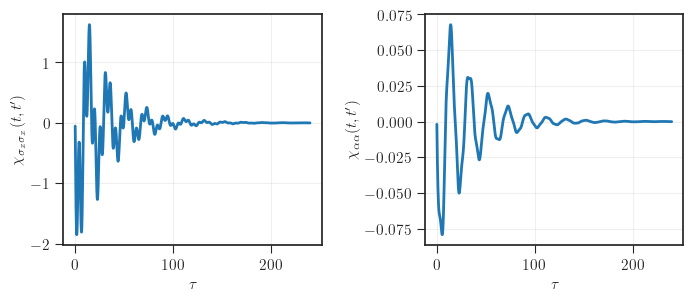

In [12]:
plt.style.use(['seaborn-v0_8-white', './style.mplstyle'])

fig, ax = plt.subplots(1, 2, figsize=(8, 3))
plt.subplots_adjust(wspace=0.4)

ax[0].plot(tau_grid_resp_spin, chi_spin, linewidth = 2)
ax[0].grid(alpha = 0.3)
ax[0].set_xlabel(r'$\tau$')
ax[0].set_ylabel(r"$\chi_{\sigma_x\sigma_x}(t, t')$")

ax[1].plot(tau_grid_resp_cavity, chi_cav, linewidth = 2)
ax[1].grid(alpha = 0.3)
ax[1].set_xlabel(r'$\tau$')
ax[1].set_ylabel(r"$\chi_{\alpha\alpha}(t, t')$")

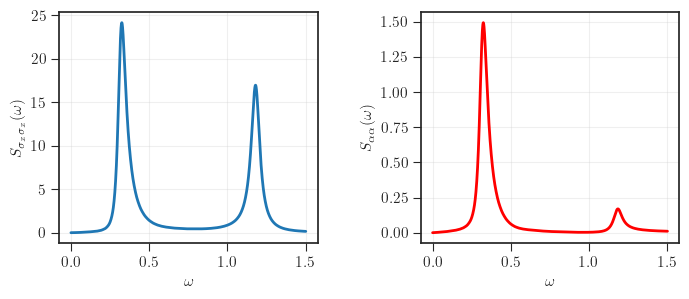

In [13]:
plt.style.use(['seaborn-v0_8-white', './style.mplstyle'])

fig, ax = plt.subplots(1, 2, figsize=(8, 3))
plt.subplots_adjust(wspace=0.4)

ax[0].plot(w_grid, -imag_chi_spin_w, linewidth = 2)
ax[0].grid(alpha = 0.3)
ax[0].set_xlabel(r'$\omega$')
ax[0].set_ylabel(r"$S_{\sigma_x\sigma_x}(\omega)$")

ax[1].plot(w_grid, -imag_chi_cav_w, linewidth = 2, color = 'r')
ax[1].grid(alpha = 0.3)
ax[1].set_xlabel(r'$\omega$')
ax[1].set_ylabel(r"$S_{\alpha\alpha}(\omega)$")

plt.show()

In [14]:
coth_theoretical = 2.0/jnp.tanh(w_grid / (2.0 * p['T'] + 1e-12))
classical = 2*p['T']/w_grid

raw_ratio_spin = S_w_spin / (jnp.abs(imag_chi_spin_w) + 1e-12)
raw_ratio_cavity = S_w_cavity / (jnp.abs(imag_chi_cav_w) + 1e-12)

ratio_spin = raw_ratio_spin * j_val
ratio_cavity = raw_ratio_cavity * jnp.sqrt(j_val)

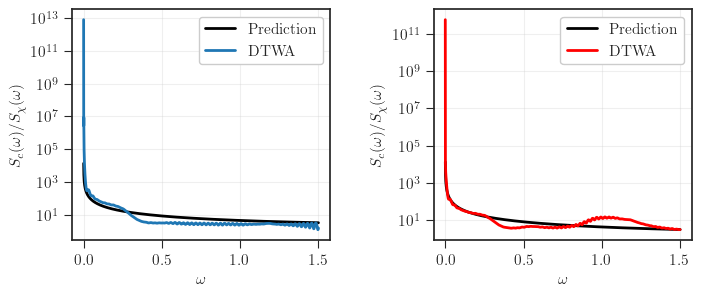

In [15]:
plt.style.use(['seaborn-v0_8-white', './style.mplstyle'])

fig, ax = plt.subplots(1, 2, figsize=(8, 3))
plt.subplots_adjust(wspace=0.4)

ax[0].semilogy(w_grid, coth_theoretical, linewidth = 2, label = 'Prediction', color = 'k')
ax[0].semilogy(w_grid, ratio_spin, linewidth = 2, label = 'DTWA')
ax[0].grid(alpha = 0.3)
ax[0].set_xlabel(r'$\omega$')
ax[0].set_ylabel(r"$S_{c}(\omega)/S_{\chi}(\omega)$")
ax[0].legend()

ax[1].semilogy(w_grid, coth_theoretical, linewidth = 2, label = 'Prediction', color = 'k')
ax[1].semilogy(w_grid, ratio_cavity, linewidth = 2, label = 'DTWA', color = 'r')
ax[1].grid(alpha = 0.3)
ax[1].set_xlabel(r'$\omega$')
ax[1].set_ylabel(r"$S_{c}(\omega)/S_{\chi}(\omega)$")
ax[1].legend()

plt.show()